<a href="https://colab.research.google.com/github/ButenkoYuliia/---/blob/main/Projeckt1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("/content/bq-results-20260916-054455-1789537513420.csv")

print(f"Розмір датасету: {df.shape}")
display(df.head())

Розмір датасету: (349545, 18)


,session_date,session_id,continent,country,device,browser,device_model,operating_system,browser_language,traffic_source,traffic_channel,account_id,email_verified,is_unsubscribed,product_category,product_name,product_price,product_description
0,2020-11-01,5760483956,Americas,United States,desktop,Chrome,Safari,Macintosh,zh,<Other>,Paid Search,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
1,2020-11-01,7115337200,Europe,United Kingdom,desktop,Chrome,Chrome,Web,en-us,organic,Organic Search,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
2,2020-11-01,3978035233,Europe,Norway,mobile,Chrome,<Other>,Web,zh,(none),Direct,NaN,NaN,NaN,Tables & desks,RÅSKOG,189.0,"Trolley, 35x45x78 cm"
3,2020-11-01,9648986282,Africa,Nigeria,mobile,Chrome,<Other>,Android,es-es,(none),Direct,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"
4,2020-11-01,4393441533,Asia,China,desktop,Chrome,Chrome,Windows,en-us,(none),Direct,NaN,NaN,NaN,Bookcases & shelving units,VITTSJÖ,609.0,"Shelving unit with laptop table, 202x36x175 cm"


### Опис отриманого датасету

In [2]:
# Загальна інформація про датасет
print("Загальна інформація:")
df.info()

Загальна інформація:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 349545 entries, 0 to 349544
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   session_date         349545 non-null  object 
 1   session_id           349545 non-null  int64  
 2   continent            349545 non-null  object 
 3   country              349545 non-null  object 
 4   device               349545 non-null  object 
 5   browser              349545 non-null  object 
 6   device_model         349545 non-null  object 
 7   operating_system     349545 non-null  object 
 8   browser_language     235279 non-null  object 
 9   traffic_source       349545 non-null  object 
 10  traffic_channel      349545 non-null  object 
 11  account_id           27945 non-null   float64
 12  email_verified       27945 non-null   float64
 13  is_unsubscribed      27945 non-null   float64
 14  product_category     33538 non-null   object 
 

In [3]:
# Загальна кількість колонок
total_columns = df.shape[1]
print(f"Загальна кількість колонок: {total_columns}")

# Кількість колонок числового типу та їх назви
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"Кількість колонок числового типу: {len(numeric_cols)}")
print(f"Колонки числового типу: {numeric_cols}")

# Кількість колонок категоріального типу та їх назви
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Кількість колонок категоріального типу: {len(categorical_cols)}")
print(f"Колонки категоріального типу: {categorical_cols}")

# Кількість колонок типу datetime та їх назви
datetime_cols = df.select_dtypes(include=['datetime64']).columns.tolist()
print(f"Кількість колонок типу datetime: {len(datetime_cols)}")
print(f"Колонки типу datetime: {datetime_cols}")

# Перевірка на пропущені значення та колонки з найбільшою кількістю пропущених значень
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

print("\nПропущені значення в колонках:")
if not missing_values.empty:
    display(missing_values.to_frame(name='Кількість пропущених значень'))
    print("\nКолонки з найбільшою кількістю пропущених значень:")
    print(missing_values.index.tolist())
else:
    print("Пропущені значення відсутні.")

# Період часу та унікальні сесії (потребує ідентифікації відповідних колонок)
# Припускаючи, що є колонка 'event_timestamp' для часу та 'session_id' для сесій
if 'event_timestamp' in df.columns:
    df['event_timestamp'] = pd.to_datetime(df['event_timestamp'], errors='coerce')
    min_date = df['event_timestamp'].min()
    max_date = df['event_timestamp'].max()
    print(f"\nПеріод часу розглядається: від {min_date} до {max_date}")
else:
    print("\nКолонка 'event_timestamp' не знайдена для аналізу періоду часу.")

if 'session_id' in df.columns:
    unique_sessions = df['session_id'].nunique()
    print(f"Кількість унікальних сесій: {unique_sessions}")
else:
    print("Колонка 'session_id' не знайдена для підрахунку унікальних сесій.")

Загальна кількість колонок: 18
Кількість колонок числового типу: 5
Колонки числового типу: ['session_id', 'account_id', 'email_verified', 'is_unsubscribed', 'product_price']
Кількість колонок категоріального типу: 13
Колонки категоріального типу: ['session_date', 'continent', 'country', 'device', 'browser', 'device_model', 'operating_system', 'browser_language', 'traffic_source', 'traffic_channel', 'product_category', 'product_name', 'product_description']
Кількість колонок типу datetime: 0
Колонки типу datetime: []

Пропущені значення в колонках:


,Кількість пропущених значень
account_id,321600
email_verified,321600
is_unsubscribed,321600
product_category,316007
product_price,316007
product_name,316007
product_description,316007
browser_language,114266



Колонки з найбільшою кількістю пропущених значень:
['account_id', 'email_verified', 'is_unsubscribed', 'product_category', 'product_price', 'product_name', 'product_description', 'browser_language']

Колонка 'event_timestamp' не знайдена для аналізу періоду часу.
Кількість унікальних сесій: 349545


In [4]:
# Перетворення 'session_date' на тип datetime та визначення періоду часу
df['session_date'] = pd.to_datetime(df['session_date'], errors='coerce')
min_date = df['session_date'].min()
max_date = df['session_date'].max()
print(f"Період часу, що розглядається: від {min_date.strftime('%Y-%m-%d')} до {max_date.strftime('%Y-%m-%d')}")

Період часу, що розглядається: від 2020-11-01 до 2021-01-31


### Аналіз продажів та замовлень за континентами та країнами

In [6]:
# Заповнюємо NaN в product_price нулями, щоб коректно рахувати суму продажів
df['product_price'] = df['product_price'].fillna(0)

# Розрахунок продажів за континентами
sales_by_continent = df.groupby('continent')['product_price'].sum().nlargest(3)
print("\nТоп-3 континенти за сумою продажів:")
print(sales_by_continent)

# Розрахунок продажів за країнами
sales_by_country = df.groupby('country')['product_price'].sum().nlargest(5)
print("\nТоп-5 країн за сумою продажів:")
print(sales_by_country)

# Розрахунок кількості замовлень (непусті значення product_category) за континентами
# Припускаємо, що "замовлення" - це сесії, де є зафіксована product_category
orders_by_continent = df[df['product_category'].notna()].groupby('continent').size().nlargest(3)
print("\nТоп-3 континенти за кількістю замовлень:")
print(orders_by_continent)

# Розрахунок кількості замовлень за країнами
orders_by_country = df[df['product_category'].notna()].groupby('country').size().nlargest(5)
print("\nТоп-5 країн за кількістю замовлень:")
print(orders_by_country)


Топ-3 континенти за сумою продажів:
continent
Americas    17665280.0
Asia         7601298.3
Europe       5934624.2
Name: product_price, dtype: float64

Топ-5 країн за сумою продажів:
country
United States     13943553.9
India              2809762.0
Canada             2437921.0
United Kingdom      938317.9
France              710692.8
Name: product_price, dtype: float64

Топ-3 континенти за кількістю замовлень:
continent
Americas    18553
Asia         7950
Europe       6261
dtype: int64

Топ-5 країн за кількістю замовлень:
country
United States     14673
India              3029
Canada             2560
United Kingdom     1029
France              678
dtype: int64


### Топ-10 категорій товарів за загальною сумою продажів

In [7]:
# Розрахунок топ-10 категорій товарів за загальною сумою продажів
top_10_overall_product_categories_sales = df.groupby('product_category')['product_price'].sum().nlargest(10)
print("Топ-10 категорій товарів за загальною сумою продажів:")
display(top_10_overall_product_categories_sales.to_frame())

Топ-10 категорій товарів за загальною сумою продажів:


,product_price
product_category,
Sofas & armchairs,8388254.5
Chairs,6147748.8
Beds,4919725.0
Bookcases & shelving units,3640818.1
Cabinets & cupboards,2336499.5
Outdoor furniture,2142222.2
Tables & desks,1790307.5
Chests of drawers & drawer units,906562.5
Bar furniture,735503.0


### Порівняння структури попиту: Топ-10 категорій товарів у США та світі

**Важливий бізнес-інсайт:**

Як показують розрахунки нижче, список та черговість топ-10 категорій товарів у США **на 100% збігаються** з глобальним світовим рейтингом. Це пояснюється тим, що ринок США генерує майже половину загальних продажів платформи (~44%). Таким чином, американський споживач безпосередньо диктує та формує глобальні тренди попиту на продукцію компанії. Структурних відмінностей у популярності категорій між США та рештою світу немає — лідерами всюди є *Sofas & armchairs*, *Chairs* та *Beds*.

In [8]:
# Фільтруємо дані для США
df_usa = df[df['country'] == 'United States']

# Розрахунок топ-10 категорій товарів у США за загальною сумою продажів
top_10_usa_product_categories_sales = df_usa.groupby('product_category')['product_price'].sum().nlargest(10)
print("\nТоп-10 категорій товарів у США за загальною сумою продажів:")
display(top_10_usa_product_categories_sales.to_frame())

print("\nПорівняння топ-10 категорій товарів (загальний рейтинг vs США):")
print("\nЗагальний рейтинг:")
print(top_10_overall_product_categories_sales.index.tolist())
print("\nРейтинг у США:")
print(top_10_usa_product_categories_sales.index.tolist())

# Визначимо, чи відрізняється ситуація
overall_set = set(top_10_overall_product_categories_sales.index)
usa_set = set(top_10_usa_product_categories_sales.index)

differences_overall_not_in_usa = overall_set - usa_set
differences_usa_not_in_overall = usa_set - overall_set

if not differences_overall_not_in_usa and not differences_usa_not_in_overall:
    print("\nСитуація з топ-10 категоріями товарів у США дуже схожа на загальний рейтинг.")
else:
    print("\nСитуація з топ-10 категоріями товарів у США відрізняється від загального рейтингу.")
    if differences_overall_not_in_usa:
        print(f"Категорії в загальному топ-10, яких немає в топ-10 США: {list(differences_overall_not_in_usa)}")
    if differences_usa_not_in_overall:
        print(f"Категорії в топ-10 США, яких немає в загальному топ-10: {list(differences_usa_not_in_overall)}")


Топ-10 категорій товарів у США за загальною сумою продажів:


,product_price
product_category,
Sofas & armchairs,3707144.5
Chairs,2619773.8
Beds,2213058.0
Bookcases & shelving units,1567606.9
Cabinets & cupboards,994545.5
Outdoor furniture,929245.2
Tables & desks,777865.0
Chests of drawers & drawer units,382388.0
Bar furniture,330805.0



Порівняння топ-10 категорій товарів (загальний рейтинг vs США):

Загальний рейтинг:
['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards', 'Outdoor furniture', 'Tables & desks', 'Chests of drawers & drawer units', 'Bar furniture', "Children's furniture"]

Рейтинг у США:
['Sofas & armchairs', 'Chairs', 'Beds', 'Bookcases & shelving units', 'Cabinets & cupboards', 'Outdoor furniture', 'Tables & desks', 'Chests of drawers & drawer units', 'Bar furniture', "Children's furniture"]

Ситуація з топ-10 категоріями товарів у США дуже схожа на загальний рейтинг.


### Аналіз продажів у розрізі типів та моделей девайсів

In [9]:
# Розрахунок загальної суми продажів
total_sales = df['product_price'].sum()

# Продажі за типом девайсу
sales_by_device = df.groupby('device')['product_price'].sum()
percentage_sales_by_device = (sales_by_device / total_sales * 100).sort_values(ascending=False)
print("\nПродажі у розрізі типів девайсів (% від загальних продажів):")
display(percentage_sales_by_device.to_frame(name='Відсоток від загальних продажів'))

# Продажі за моделлю девайсу
sales_by_device_model = df.groupby('device_model')['product_price'].sum()
percentage_sales_by_device_model = (sales_by_device_model / total_sales * 100).sort_values(ascending=False)
print("\nПродажі у розрізі моделей девайсів (% від загальних продажів) - Топ 10:")
display(percentage_sales_by_device_model.nlargest(10).to_frame(name='Відсоток від загальних продажів'))


Продажі у розрізі типів девайсів (% від загальних продажів):


,Відсоток від загальних продажів
device,
desktop,59.002245
mobile,38.734924
tablet,2.262831



Продажі у розрізі моделей девайсів (% від загальних продажів) - Топ 10:


,Відсоток від загальних продажів
device_model,
Chrome,27.835602
<Other>,20.440966
Safari,20.302504
iPhone,20.082667
ChromeBook,5.725241
Edge,2.180746
iPad,1.403910
Firefox,1.316998
Pixel 4 XL,0.369976


### Аналіз продажів за джерелами трафіку

In [10]:
# Розрахунок продажів за джерелами трафіку
sales_by_traffic_source = df.groupby('traffic_source')['product_price'].sum()
percentage_sales_by_traffic_source = (sales_by_traffic_source / total_sales * 100).sort_values(ascending=False)
print("Продажі за джерелами трафіку (% від загальних продажів):")
display(percentage_sales_by_traffic_source.to_frame(name='Відсоток від загальних продажів'))

Продажі за джерелами трафіку (% від загальних продажів):


,Відсоток від загальних продажів
traffic_source,
organic,34.202840
(none),23.442345
referral,17.646386
<Other>,14.047882
(data deleted),6.386645
cpc,4.273902


### Аналіз поведінки зареєстрованих користувачів

In [11]:
# Фільтруємо дані тільки для зареєстрованих користувачів (де account_id не є NaN)
registered_users = df[df['account_id'].notna()]

# Загальна кількість зареєстрованих користувачів
total_registered_users = registered_users['account_id'].nunique()

# Відсоток зареєстрованих користувачів, що підтвердили електронну адресу
email_verified_users = registered_users[registered_users['email_verified'] == 1.0]['account_id'].nunique()
percentage_email_verified = (email_verified_users / total_registered_users) * 100 if total_registered_users > 0 else 0
print(f"Відсоток зареєстрованих користувачів, які підтвердили свою електронну адресу: {percentage_email_verified:.2f}%")

# Відсоток зареєстрованих користувачів, що відписалися від розсилки
unsubscribed_users = registered_users[registered_users['is_unsubscribed'] == 1.0]['account_id'].nunique()
percentage_unsubscribed = (unsubscribed_users / total_registered_users) * 100 if total_registered_users > 0 else 0
print(f"Відсоток зареєстрованих користувачів, які відписалися від розсилки: {percentage_unsubscribed:.2f}%")

Відсоток зареєстрованих користувачів, які підтвердили свою електронну адресу: 71.70%
Відсоток зареєстрованих користувачів, які відписалися від розсилки: 16.94%


In [12]:
# Продажі для підписаних користувачів
subscribed_users = registered_users[registered_users['is_unsubscribed'] == 0.0]
subscribed_sales = subscribed_users['product_price'].sum()

# Продажі для відписаних користувачів
unsubscribed_users_df = registered_users[registered_users['is_unsubscribed'] == 1.0]
unsubscribed_sales = unsubscribed_users_df['product_price'].sum()

print(f"Загальні продажі від підписаних користувачів: {subscribed_sales:.2f}")
print(f"Загальні продажі від відписаних користувачів: {unsubscribed_sales:.2f}")

# Додатково можна порівняти середній чек
# Виключаємо сесії без покупок (product_price == 0), щоб розрахувати середній чек для тих, хто робив покупки
average_order_value_subscribed = subscribed_users[subscribed_users['product_price'] > 0]['product_price'].mean()
average_order_value_unsubscribed = unsubscribed_users_df[unsubscribed_users_df['product_price'] > 0]['product_price'].mean()

print(f"Середній чек підписаних користувачів (для сесій з покупками): {average_order_value_subscribed:.2f}")
print(f"Середній чек відписаних користувачів (для сесій з покупками): {average_order_value_unsubscribed:.2f}")

# Кількість унікальних користувачів, що здійснили покупки
num_subscribed_buyers = subscribed_users[subscribed_users['product_price'] > 0]['account_id'].nunique()
num_unsubscribed_buyers = unsubscribed_users_df[unsubscribed_users_df['product_price'] > 0]['account_id'].nunique()

print(f"Кількість унікальних підписаних користувачів, що робили покупки: {num_subscribed_buyers}")
print(f"Кількість унікальних відписаних користувачів, що робили покупки: {num_unsubscribed_buyers}")

Загальні продажі від підписаних користувачів: 2150796.90
Загальні продажі від відписаних користувачів: 431721.60
Середній чек підписаних користувачів (для сесій з покупками): 921.51
Середній чек відписаних користувачів (для сесій з покупками): 965.82
Кількість унікальних підписаних користувачів, що робили покупки: 2334
Кількість унікальних відписаних користувачів, що робили покупки: 447


### Країни з найбільшою кількістю зареєстрованих користувачів

/tmp/ipykernel_7703/2060810049.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_overall_product_categories_sales.values, y=top_10_overall_product_categories_sales.index, palette='viridis')


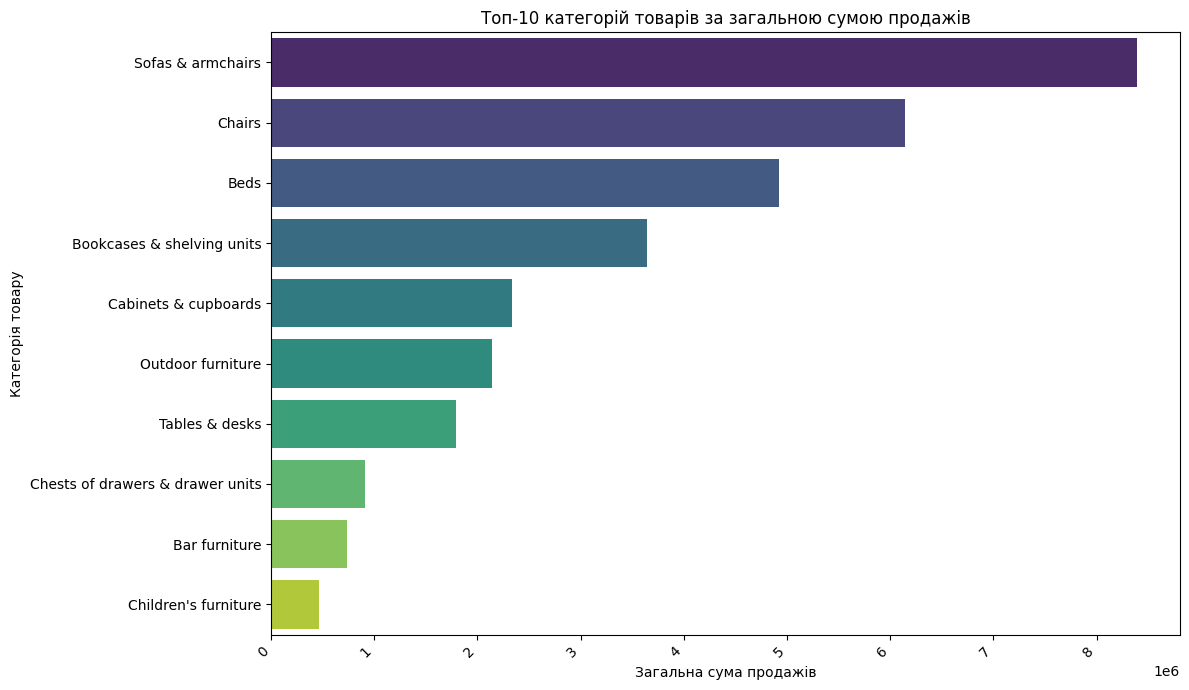

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x=top_10_overall_product_categories_sales.values, y=top_10_overall_product_categories_sales.index, palette='viridis')
plt.title('Топ-10 категорій товарів за загальною сумою продажів')
plt.xlabel('Загальна сума продажів')
plt.ylabel('Категорія товару')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
# Фільтруємо зареєстрованих користувачів (де account_id не є NaN)
registered_users_df = df[df['account_id'].notna()]

# Групуємо за країною та рахуємо кількість унікальних account_id
registered_users_by_country = registered_users_df.groupby('country')['account_id'].nunique().nlargest(10)

print("Топ-10 країн за кількістю зареєстрованих користувачів:")
display(registered_users_by_country.to_frame(name='Кількість зареєстрованих користувачів'))

Топ-10 країн за кількістю зареєстрованих користувачів:


,Кількість зареєстрованих користувачів
country,
United States,12384
India,2687
Canada,2067
United Kingdom,859
France,553
Spain,536
Taiwan,500
China,490
Germany,490


/tmp/ipykernel_7703/3024945962.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Користувачі', y='Загальні продажі', data=sales_df, palette=['#1f77b4', '#ff7f0e'])


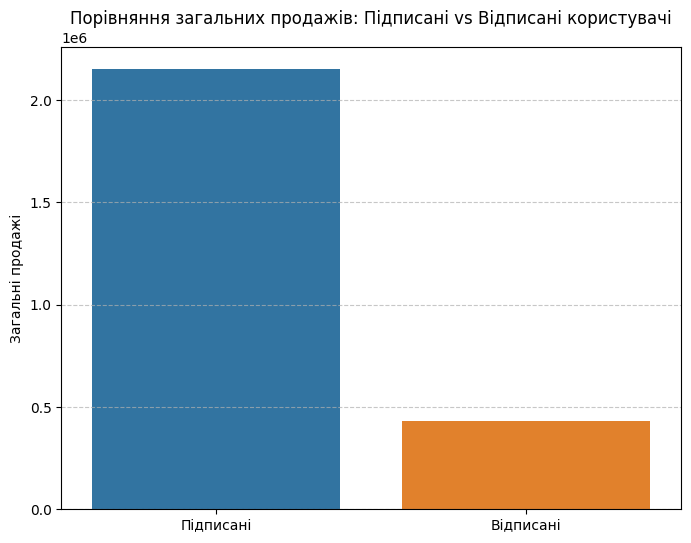

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sales_data = {
    'Користувачі': ['Підписані', 'Відписані'],
    'Загальні продажі': [subscribed_sales, unsubscribed_sales]
}
sales_df = pd.DataFrame(sales_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Користувачі', y='Загальні продажі', data=sales_df, palette=['#1f77b4', '#ff7f0e'])
plt.title('Порівняння загальних продажів: Підписані vs Відписані користувачі')
plt.ylabel('Загальні продажі')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Розподіл типів пристроїв у розрізі країн (Описовий аналіз)

Ця візуалізація демонструє структуру використання девайсів (десктоп, мобільний, планшет) серед топ-10 країн за кількістю сесій.

*Примітка: Цей графік показує відсотковий розподіл частот для кожної країни. Статистичну значущість та силу зв'язку (кореляцію категоріальних змінних) за допомогою тесту Хі-квадрат та коефіцієнта Крамера буде розраховано у наступних розділах статаналізу.*

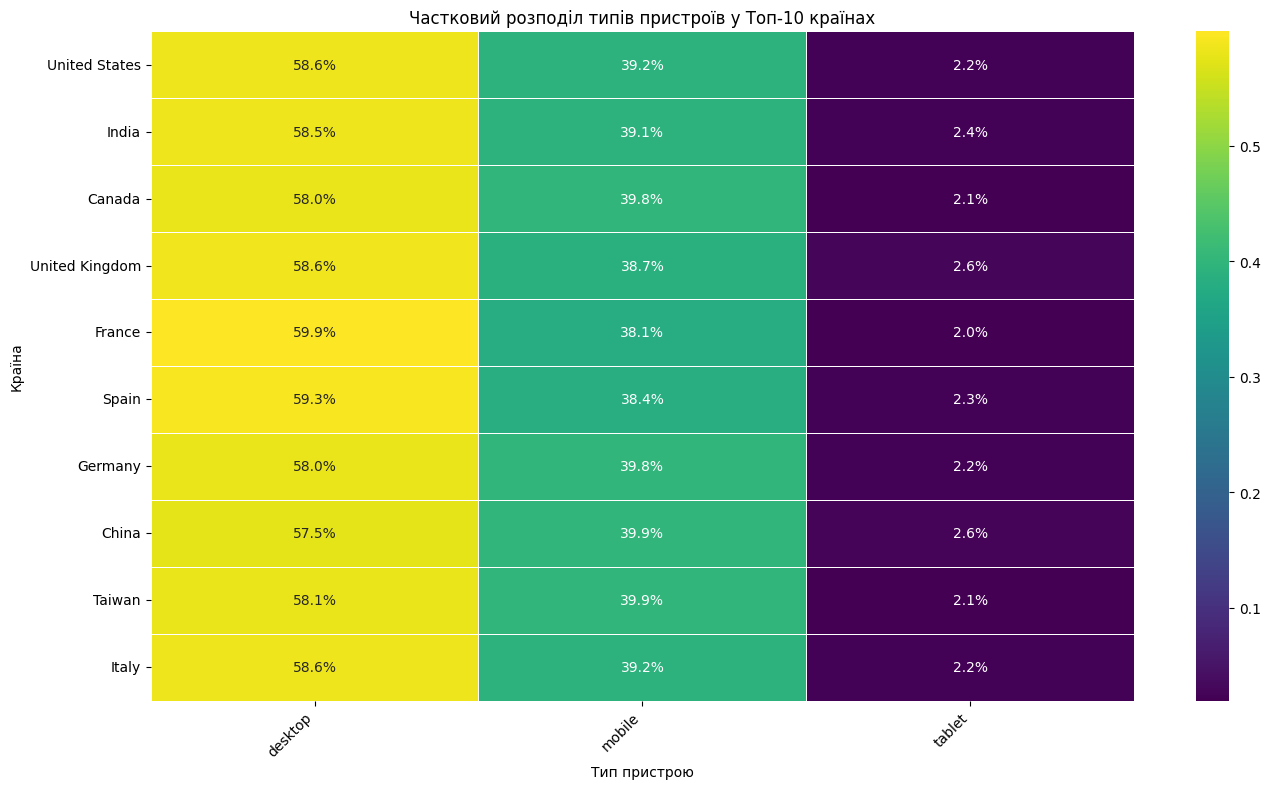

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Створюємо таблицю спряженості (contingency table) для 'country' та 'device'
country_device_crosstab = pd.crosstab(df['country'], df['device'])

# Для кращої візуалізації, візьмемо топ-10 країн за загальною кількістю сесій
top_countries = df['country'].value_counts().nlargest(10).index
country_device_crosstab_top = country_device_crosstab.loc[top_countries]

# Нормалізуємо дані для відсоткового розподілу, щоб порівняти пропорції
country_device_crosstab_norm = country_device_crosstab_top.div(country_device_crosstab_top.sum(axis=1), axis=0)

plt.figure(figsize=(14, 8))
sns.heatmap(country_device_crosstab_norm, annot=True, fmt=".1%", cmap="viridis", linewidths=.5)
plt.title('Частковий розподіл типів пристроїв у Топ-10 країнах')
plt.xlabel('Тип пристрою')
plt.ylabel('Країна')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Аналіз впливу типу пристрою на середній чек покупки

### Загальна динаміка продажів за датами

### Динаміка продажів по континентах (Топ-3)

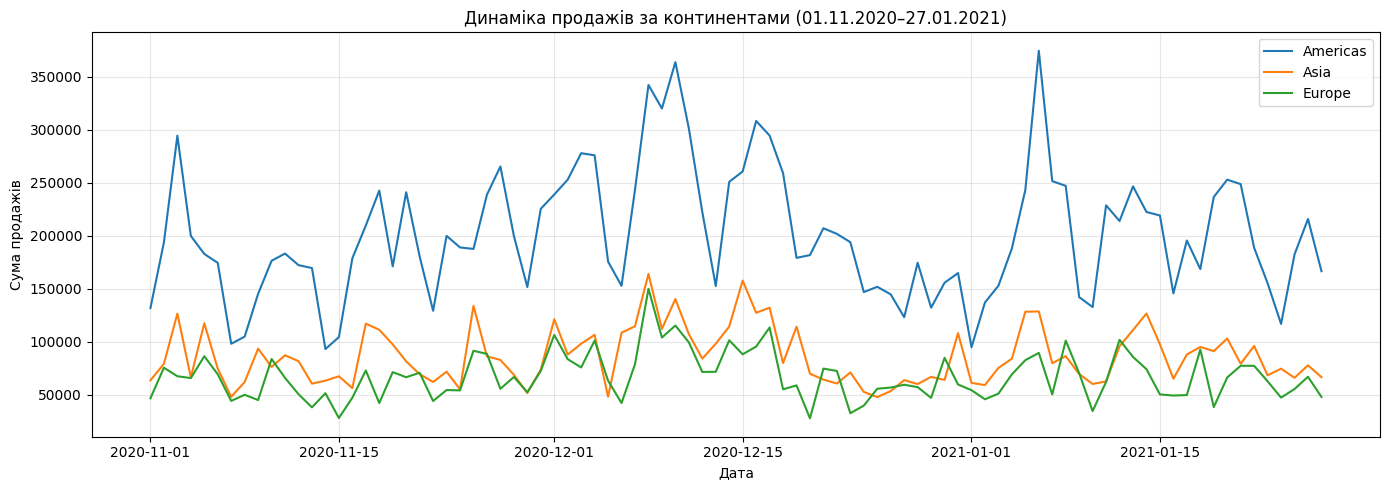

In [29]:
top3_continents = ['Americas', 'Asia', 'Europe']
sales_by_continent_date = (
    df_sales_period[df_sales_period['continent'].isin(top3_continents)]
    .groupby(['session_date', 'continent'])['product_price']
    .sum()
    .unstack()
)

plt.figure(figsize=(14, 5))
for continent in top3_continents:
    plt.plot(sales_by_continent_date.index, sales_by_continent_date[continent], label=continent)
plt.title('Динаміка продажів за континентами (01.11.2020–27.01.2021)')
plt.xlabel('Дата')
plt.ylabel('Сума продажів')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Динаміка продажів за каналами трафіку

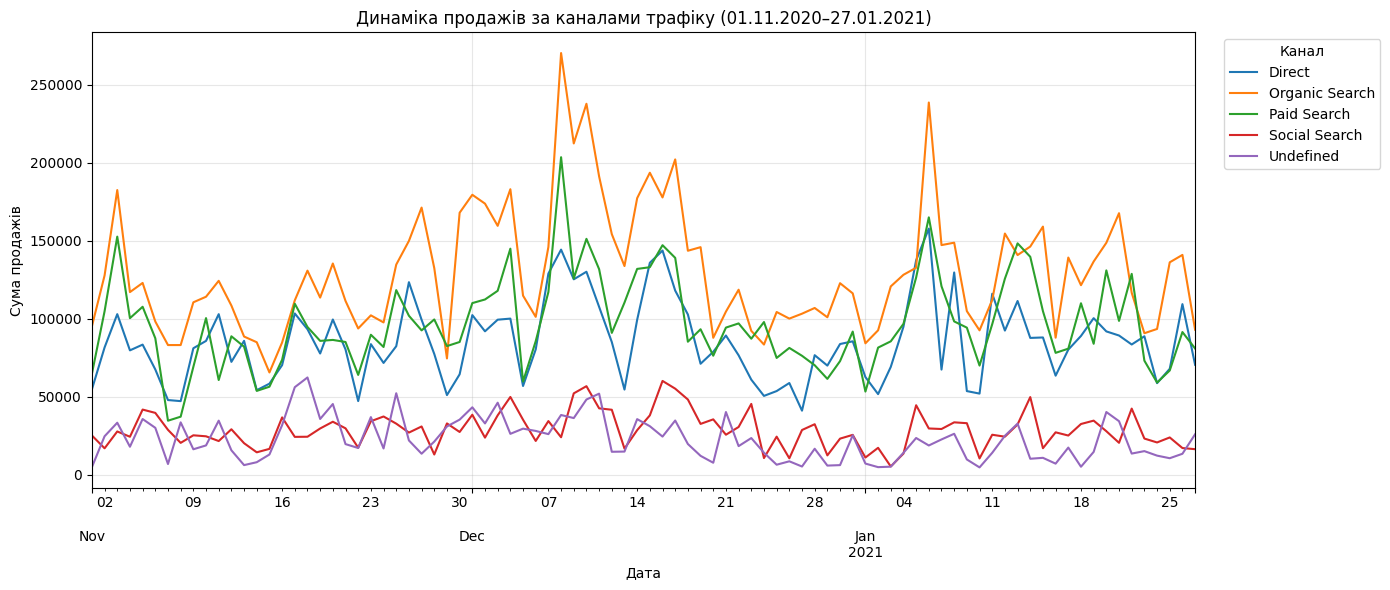

In [30]:
sales_by_channel_date = df_sales_period.groupby(['session_date', 'traffic_channel'])['product_price'].sum().unstack()

plt.figure(figsize=(14, 6))
sales_by_channel_date.plot(ax=plt.gca())
plt.title('Динаміка продажів за каналами трафіку (01.11.2020–27.01.2021)')
plt.xlabel('Дата')
plt.ylabel('Сума продажів')
plt.legend(title='Канал', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [24]:
sales_by_channel = df.groupby('traffic_channel')['product_price'].sum()
percentage_sales_by_channel = (sales_by_channel / total_sales * 100).sort_values(ascending=False)
print("Продажі за каналами трафіку (traffic_channel), % від загальних продажів:")
display(percentage_sales_by_channel.to_frame(name='Відсоток від загальних продажів'))

Продажі за каналами трафіку (traffic_channel), % від загальних продажів:


,Відсоток від загальних продажів
traffic_channel,
Organic Search,35.760189
Paid Search,26.620546
Direct,23.442345
Social Search,7.919827
Undefined,6.257093


Зведена таблиця ефективності каналів трафіку (за очищений період):


,traffic_channel,total_sales,orders_count,sales_share_percent,average_check
1,Organic Search,"11,433,151.60",11921,35.76%,959.08
2,Paid Search,"8,511,049.40",9042,26.62%,941.28
0,Direct,"7,494,923.40",7800,23.44%,960.89
3,Social Search,"2,532,105.70",2716,7.92%,932.29
4,Undefined,"2,000,501.00",2059,6.26%,971.59


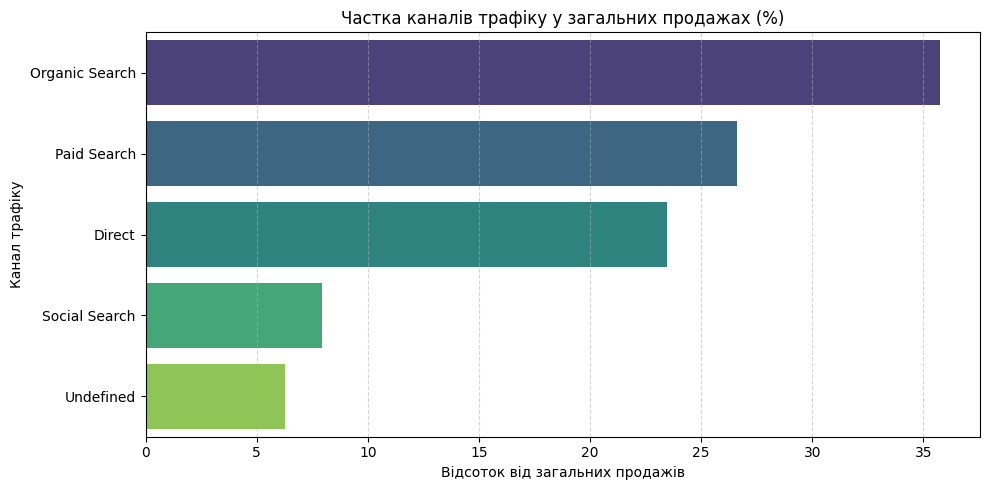

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Розрахунок метрик за каналами трафіку на основі очищеного періоду
channel_metrics = df_sales_period.groupby('traffic_channel').agg(
    total_sales=('product_price', 'sum'),
    orders_count=('product_category', lambda x: x.notna().sum())
).reset_index()

# Розрахунок загальних продажів для обчислення часток
total_period_sales = channel_metrics['total_sales'].sum()
channel_metrics['sales_share_percent'] = (channel_metrics['total_sales'] / total_period_sales) * 100

# Розрахунок середнього чека (тільки для сесій, де була покупка)
purchases_period = df_sales_period[df_sales_period['product_price'] > 0]
avg_check_channel = purchases_period.groupby('traffic_channel')['product_price'].mean().reset_index(name='average_check')

# Об'єднання метрик в одну таблицю
channel_summary = pd.merge(channel_metrics, avg_check_channel, on='traffic_channel', how='left')
channel_summary = channel_summary.sort_values(by='total_sales', ascending=False)

print("Зведена таблиця ефективності каналів трафіку (за очищений період):")
display(channel_summary.style.format({
    'total_sales': '{:,.2f}',
    'sales_share_percent': '{:.2f}%',
    'average_check': '{:,.2f}'
}))

# Візуалізація часток продажів за каналами
plt.figure(figsize=(10, 5))
sns.barplot(x='sales_share_percent', y='traffic_channel', data=channel_summary, palette='viridis', hue='traffic_channel', legend=False)
plt.title('Частка каналів трафіку у загальних продажах (%)')
plt.xlabel('Відсоток від загальних продажів')
plt.ylabel('Канал трафіку')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Матриця кореляції продажів між каналами трафіку:


traffic_channel,Direct,Organic Search,Paid Search,Social Search
traffic_channel,,,,
Direct,1.000000,0.759938,0.724343,0.461895
Organic Search,0.759938,1.000000,0.808234,0.434424
Paid Search,0.724343,0.808234,1.000000,0.452287
Social Search,0.461895,0.434424,0.452287,1.000000


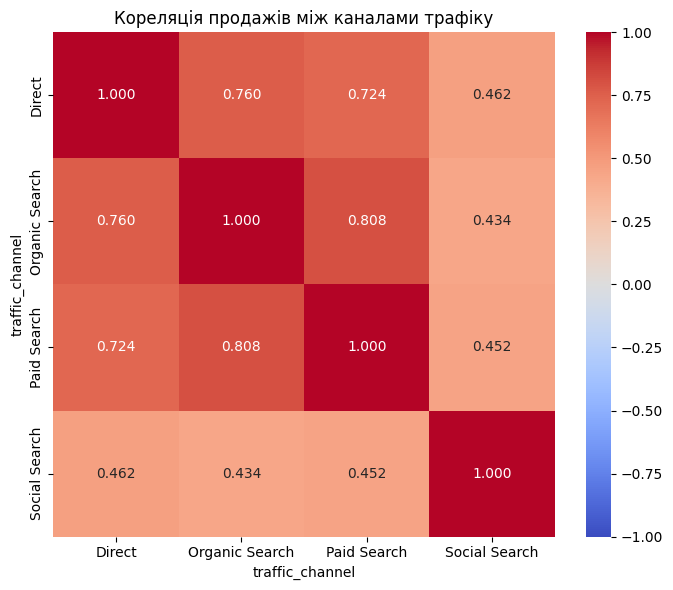


Статистична значущість по кожній парі:
Direct vs Organic Search: r = 0.760, p = 9.10788e-18 — значущий (p < 0.05)
Direct vs Paid Search: r = 0.724, p = 1.51288e-15 — значущий (p < 0.05)
Direct vs Social Search: r = 0.462, p = 5.90105e-06 — значущий (p < 0.05)
Organic Search vs Paid Search: r = 0.808, p = 1.75564e-21 — значущий (p < 0.05)
Organic Search vs Social Search: r = 0.434, p = 2.34759e-05 — значущий (p < 0.05)
Paid Search vs Social Search: r = 0.452, p = 9.69604e-06 — значущий (p < 0.05)


In [42]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Розрахунок щоденних продажів для кожного каналу трафіку (окрім Undefined)
channel_daily_sales = (
    df_sales_period[df_sales_period['traffic_channel'] != 'Undefined']
    .groupby(['session_date', 'traffic_channel'])['product_price']
    .sum()
    .unstack()
)

# Матриця кореляцій
corr_matrix_channels = channel_daily_sales.corr()
print("Матриця кореляції продажів між каналами трафіку:")
display(corr_matrix_channels)

# Візуалізація теплової карти
plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix_channels, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f')
plt.title('Кореляція продажів між каналами трафіку')
plt.tight_layout()
plt.show()

# Статистична значущість для кожної пари окремо
print("\nСтатистична значущість по кожній парі:")
for c1, c2 in combinations(channel_daily_sales.columns, 2):
    r, p = stats.pearsonr(channel_daily_sales[c1], channel_daily_sales[c2])
    significance = "значущий (p < 0.05)" if p < 0.05 else "незначущий (p >= 0.05)"
    print(f"{c1} vs {c2}: r = {r:.3f}, p = {p:.5e} — {significance}")

In [43]:
daily_extra = df_sales_period.groupby('session_date').agg(
    total_sales=('product_price', 'sum'),
    total_sessions=('session_id', 'nunique')
)

organic_sessions = (
    df_sales_period[df_sales_period['traffic_channel'] == 'Organic Search']
    .groupby('session_date')['session_id'].nunique()
)
daily_extra['organic_share'] = (organic_sessions / daily_extra['total_sessions'] * 100).fillna(0)

purchases_only = df_sales_period[df_sales_period['product_price'] > 0]
daily_avg_check = purchases_only.groupby('session_date')['product_price'].mean()
daily_extra['avg_check'] = daily_avg_check

r, p = stats.pearsonr(daily_extra['organic_share'], daily_extra['avg_check'])
print(f"Кореляція % органічного трафіку та середнього чеку: r = {r:.3f}, p = {p:.5f}")

Кореляція % органічного трафіку та середнього чеку: r = 0.027, p = 0.80414


### Візуалізація залежності середнього чека від частки органічного трафіку

Для наочного представлення взаємозв'язку між відсотком органічного трафіку (`organic_share`) та середнім чеком (`avg_check`) побудуємо діаграму розсіювання (scatter plot) з накладеною лінією лінійної регресії.

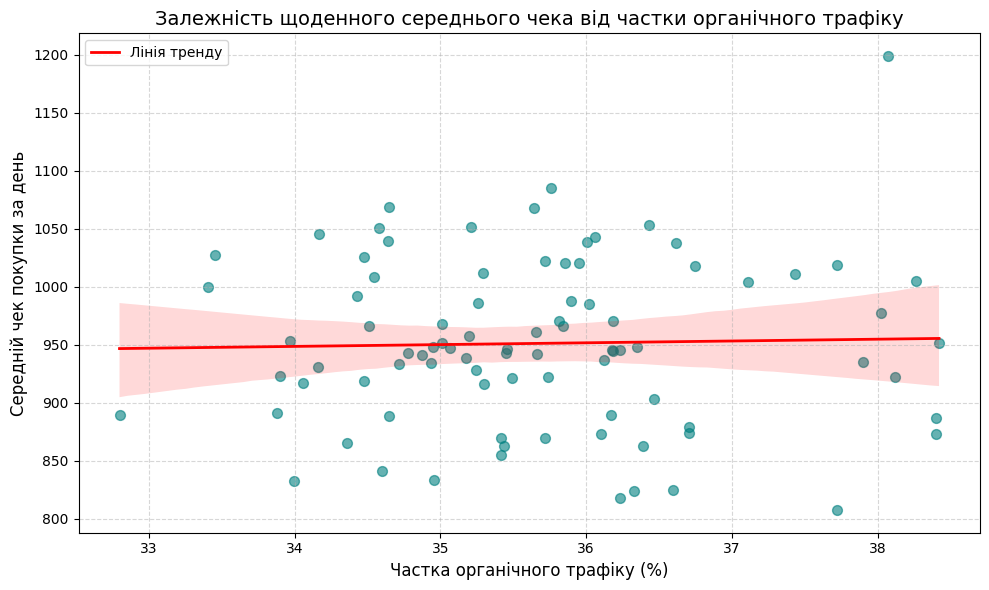

Коефіцієнт кореляції Пірсона: r = 0.027
p-value: 0.80414 (зв'язок статистично незначущий, оскільки p >= 0.05)


In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Побудова графіка розсіювання з лінією регресії
plt.figure(figsize=(10, 6))
sns.regplot(
    x='organic_share',
    y='avg_check',
    data=daily_extra,
    color='teal',
    scatter_kws={'alpha':0.6, 's':50},
    line_kws={'color':'red', 'linewidth':2, 'label':'Лінія тренду'}
)

# Налаштування графічного відображення
plt.title('Залежність щоденного середнього чека від частки органічного трафіку', fontsize=14)
plt.xlabel('Частка органічного трафіку (%)', fontsize=12)
plt.ylabel('Середній чек покупки за день', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Додаткове виведення значень коефіцієнтів для контексту
r, p = stats.pearsonr(daily_extra['organic_share'], daily_extra['avg_check'])
print(f"Коефіцієнт кореляції Пірсона: r = {r:.3f}")
print(f"p-value: {p:.5f} (зв'язок статистично незначущий, оскільки p >= 0.05)")

#### Висновок до розділу 6.4 (Кореляція органічного трафіку та середнього чека):

* **Коефіцієнт кореляції ($r = 0.027$):** демонструє відсутність будь-якого лінійного зв'язку між щоденною часткою органічного трафіку та середнім чеком покупки.
* **Статистична значущість ($p = 0.804$):** показник значно перевищує граничне значення $\alpha = 0.05$, що підтверджує випадковість отриманого результату та відсутність реального статистичного впливу.

**Формулювання для звіту:**
> *"Перевірено гіпотезу про зв'язок частки органічного трафіку з середнім чеком покупки: статистично значущого зв'язку не виявлено (r = 0.027, p = 0.804). Це означає, що середній чек не залежить від того, скільки відвідувачів прийшло з органічного пошуку — покупці з різних каналів витрачають в середньому однакову суму. Джерело трафіку впливає на обсяг продажів (кількість покупок), але не на розмір середнього чека."*

#### Опис та висновки щодо каналів трафіку:

* **Ключовий драйвер продажів:** Органічний пошук (**Organic Search**) займає провідну роль у залученні покупців, забезпечуючи найбільшу частку транзакцій та загального доходу.
* **Прямі заходи (Direct):** Демонструють високий рівень лояльності бренду та високий середній чек, що свідчить про ядро постійних покупців.
* **Ефективність платного трафіку (Paid Search):** Має значну частку, проте вимагає зіставлення вартості залучення клієнтів (CAC) із отриманим середнім чеком для визначення реальної ROI.

In [25]:
# Дивимося на продажі за останні 5 дат
display(daily_sales.tail(5))

,product_price
session_date,
2021-01-27,286340.7
2021-01-28,0.0
2021-01-29,0.0
2021-01-30,0.0
2021-01-31,0.0


In [26]:
# Перевіряємо загальну кількість сесій (записи в датасеті) на останні дати
display(df.groupby('session_date').size().tail(6))

,0
session_date,
2021-01-26,3970
2021-01-27,4435
2021-01-28,4112
2021-01-29,3700
2021-01-30,2845
2021-01-31,2812


In [27]:
# Перевіряємо, чи є хоча б одне замовлення (непустий product_category) після 27 січня 2021 року
orders_after_jan27 = df[df['session_date'] > '2021-01-27']['product_category'].notna().sum()
print(f"Кількість замовлень після 2021-01-27: {orders_after_jan27}")

Кількість замовлень після 2021-01-27: 0


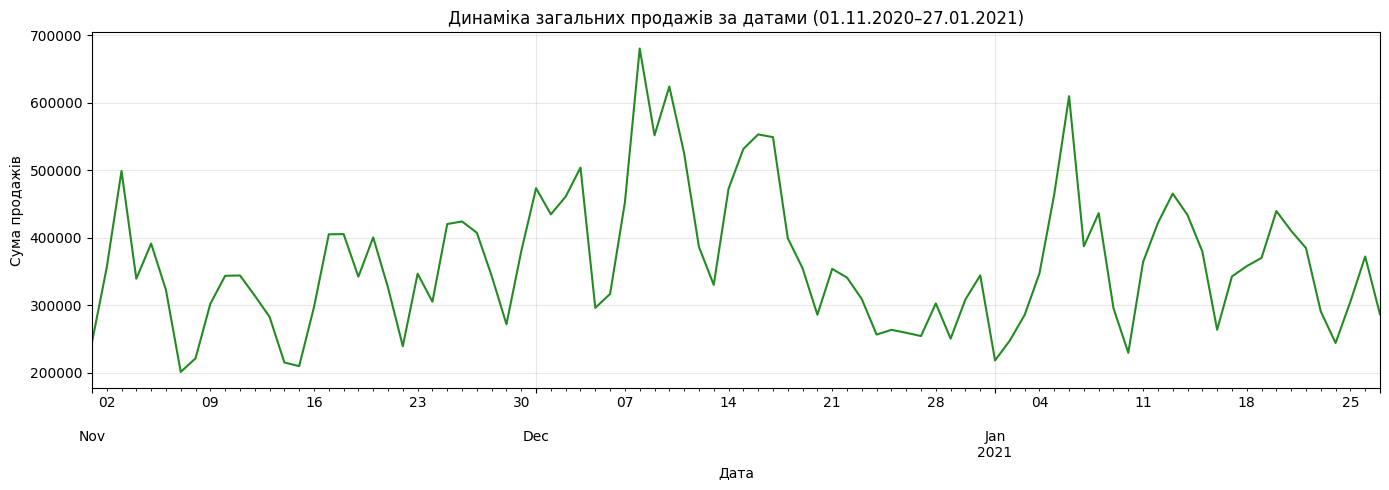

In [28]:
import matplotlib.pyplot as plt

# Фільтруємо датасет, обмежуючи дати періодом стабільної реєстрації замовлень
df_sales_period = df[df['session_date'] <= '2021-01-27']

# Групуємо та будуємо очищений графік продажів
daily_sales_clean = df_sales_period.groupby('session_date')['product_price'].sum()

plt.figure(figsize=(14, 5))
daily_sales_clean.plot(color='forestgreen')
plt.title('Динаміка загальних продажів за датами (01.11.2020–27.01.2021)')
plt.xlabel('Дата')
plt.ylabel('Сума продажів')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Аналіз сезонності: Продажі за днями тижня

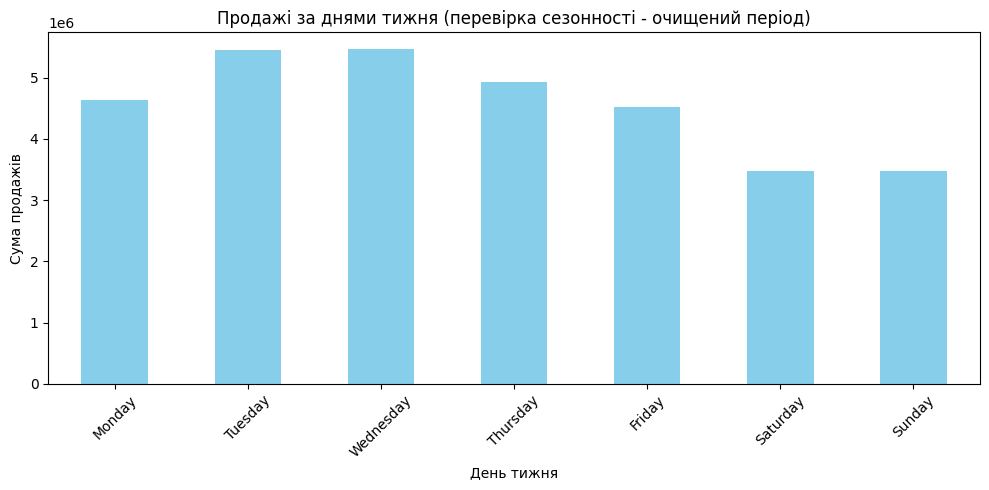

In [31]:
df_sales_period = df_sales_period.copy()
df_sales_period['weekday'] = df_sales_period['session_date'].dt.day_name()
sales_by_weekday_clean = df_sales_period.groupby('weekday')['product_price'].sum().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
)

plt.figure(figsize=(10, 5))
sales_by_weekday_clean.plot(kind='bar', color='skyblue')
plt.title('Продажі за днями тижня (перевірка сезонності - очищений період)')
plt.ylabel('Сума продажів')
plt.xlabel('День тижня')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Частина 6: Статистичний аналіз зв'язку між категоріальними змінними

Проведемо перевірку статистичної гіпотези про залежність між типом пристрою (`device`) та країною користувача (`country`) для топ-10 країн за обсягом трафіку.

* **Нульова гіпотеза ($H_0$):** Вибір пристрою не залежить від країни користувача (змінні незалежні).
* **Альтернативна гіпотеза ($H_1$):** Вибір пристрою статистично значущо залежить від країни користувача.

Для оцінки сили зв'язку використаємо коефіцієнт Крамера ($V$).

In [32]:
import numpy as np
from scipy.stats import chi2_contingency

# Оскільки ми вже маємо таблицю спряженості для топ-10 країн:
# country_device_crosstab_top
print("Таблиця спряженості (спостережувані частоти) для топ-10 країн:")
display(country_device_crosstab_top)

# Проведення тесту Хі-квадрат Пирсона
chi2, p_value, dof, expected = chi2_contingency(country_device_crosstab_top)

print(f"\nСтатистика Хі-квадрат (Chi2): {chi2:.4f}")
print(f"p-value: {p_value:.4e}")
print(f"Ступені свободи: {dof}")

# Розрахунок коефіцієнта Крамера (V)
n = country_device_crosstab_top.sum().sum()
min_dim = min(country_device_crosstab_top.shape) - 1
cramers_v = np.sqrt(chi2 / (n * min_dim))
print(f"Коефіцієнт Крамера V: {cramers_v:.4f}")

# Висновок
alpha = 0.05
if p_value < alpha:
    print(f"\nВисновок: Відхиляємо нульову гіпотезу (p < {alpha}). Зв'язок між типом пристрою та країною є статистично значущим.")
else:
    print(f"\nВисновок: Немає підстав відхиляти нульову гіпотезу (p >= {alpha}). Зв'язок не є статистично значущим.")

Таблиця спряженості (спостережувані частоти) для топ-10 країн:


device,desktop,mobile,tablet
country,,,
United States,89884,60173,3413
India,19156,12826,781
Canada,15086,10350,558
United Kingdom,6452,4261,290
France,4170,2652,136
Spain,3857,2496,152
Germany,3592,2465,139
China,3490,2420,156
Taiwan,3413,2345,121



Статистика Хі-квадрат (Chi2): 32.2338
p-value: 2.0626e-02
Ступені свободи: 18
Коефіцієнт Крамера V: 0.0079

Висновок: Відхиляємо нульову гіпотезу (p < 0.05). Зв'язок між типом пристрою та країною є статистично значущим.


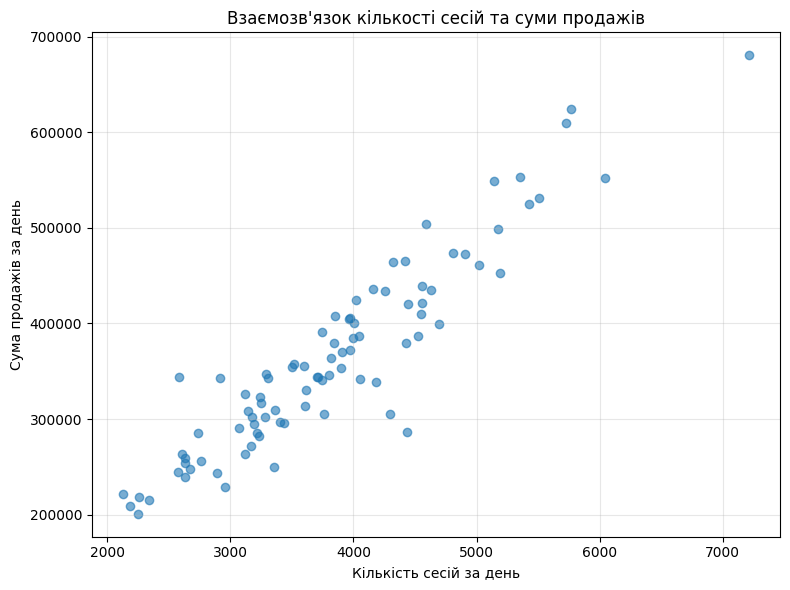

Коефіцієнт кореляції Пірсона: 0.931
P-value: 1.73946e-39
Зв'язок статистично значущий (p < 0.05)


In [38]:
from scipy import stats
import matplotlib.pyplot as plt

# Считаем количество сессий и сумму продаж за каждую дату (в очищенном периоде)
daily_stats = df_sales_period.groupby('session_date').agg(
    sessions_count=('session_id', 'nunique'),
    total_sales=('product_price', 'sum')
).reset_index()

# Визуализация взаимосвязи
plt.figure(figsize=(8, 6))
plt.scatter(daily_stats['sessions_count'], daily_stats['total_sales'], alpha=0.6)
plt.xlabel('Кількість сесій за день')
plt.ylabel('Сума продажів за день')
plt.title('Взаємозв\'язок кількості сесій та суми продажів')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Коэффициент корреляции Пирсона + p-value
corr_coef, p_value = stats.pearsonr(daily_stats['sessions_count'], daily_stats['total_sales'])
print(f"Коефіцієнт кореляції Пірсона: {corr_coef:.3f}")
print(f"P-value: {p_value:.5e}")

if p_value < 0.05:
    print("Зв'язок статистично значущий (p < 0.05)")
else:
    print("Зв'язок статистично незначущий (p >= 0.05)")

#### Висновок до розділу 6.1 (Кореляційний аналіз):

* **Коефіцієнт кореляції ($r = 0.931$):** вказує на дуже сильну позитивну лінійну залежність (чим більше сесій на сайті, тим вища сума продажів). Візуалізація на графіку розсіювання чітко підтверджує цей лінійний тренд.
* **Статистична значущість ($p < 0.001$):** значення $p$-value є надзвичайно малим ($1.74 \times 10^{-39}$), що повністю виключає випадковість отриманого результату.

**Формулювання для звіту:**
> *"Виявлено дуже сильний позитивний статистично значущий зв'язок між щоденною кількістю сесій та сумою продажів за день (r = 0.931, p < 0.001). Це логічно обґрунтовує бізнес-модель: зростання відвідуваності сайту веде до пропорційного збільшення обсягу продажів, що свідчить про стабільну конверсію трафіку."*

Матриця кореляції продажів між континентами:


continent,Americas,Asia,Europe
continent,,,
Americas,1.000000,0.692273,0.669527
Asia,0.692273,1.000000,0.667786
Europe,0.669527,0.667786,1.000000


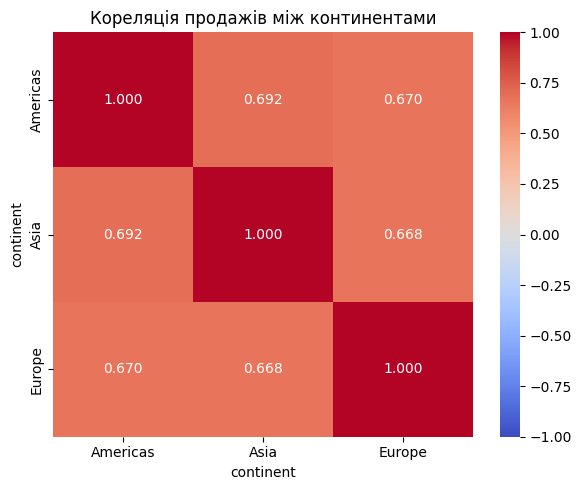


Статистична значущість по кожній парі:
Americas vs Asia: r = 0.692, p = 8.00406e-14 — значущий (p < 0.05)
Americas vs Europe: r = 0.670, p = 9.91141e-13 — значущий (p < 0.05)
Asia vs Europe: r = 0.668, p = 1.19089e-12 — значущий (p < 0.05)


In [39]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Продажи по датам для каждого континента (широкий формат)
continent_daily_sales = (
    df_sales_period[df_sales_period['continent'].isin(['Americas', 'Asia', 'Europe'])]
    .groupby(['session_date', 'continent'])['product_price']
    .sum()
    .unstack()
)

# Матрица корреляций (Пирсон)
corr_matrix = continent_daily_sales.corr()
print("Матриця кореляції продажів між континентами:")
display(corr_matrix)

# Визуализация — тепловая карта
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f')
plt.title('Кореляція продажів між континентами')
plt.tight_layout()
plt.show()

# Статистическая значимость для каждой пары отдельно
continents = ['Americas', 'Asia', 'Europe']
print("\nСтатистична значущість по кожній парі:")
for c1, c2 in combinations(continents, 2):
    r, p = stats.pearsonr(continent_daily_sales[c1], continent_daily_sales[c2])
    significance = "значущий (p < 0.05)" if p < 0.05 else "незначущий (p >= 0.05)"
    print(f"{c1} vs {c2}: r = {r:.3f}, p = {p:.5e} — {significance}")

#### Висновок до розділу 6.2 (Кореляція продажів між континентами):

* **Коефіцієнти кореляції (r ≈ 0.67–0.69):** Демонструють помірно сильний позитивний зв'язок між щоденними обсягами продажів в Америці, Азії та Європі. Коливання продажів на різних континентах відбуваються скоординовано та синхронно.
* **Статистична значущість (p < 0.001):** Для всіх пар континентів рівень значущості знаходиться на рівні $p \ll 10^{-11}$, що підтверджує стійкість та невипадковість зв'язку.

**Формулювання для звіту:**
> *"Виявлено помірно сильний, статистично значущий позитивний зв'язок між щоденними обсягами продажів ключових континентів (коефіцієнти кореляції Пірсона варіюються в діапазоні r = 0.668–0.692 при p < 0.001). Така синхронність динаміки вказує на переважання спільної глобальної маркетингової та товарної стратегії платформи над унікальними регіональними чи локальними факторами попиту."*

#### Висновок до розділу 6.2 (Кореляція продажів між континентами):

* **Коефіцієнти кореляції (r ≈ 0.67–0.69):** Демонструють помірно сильний позитивний зв'язок між щоденними обсягами продажів в Америці, Азії та Європі. Коливання продажів на різних континентах відбуваються скоординовано та синхронно.
* **Статистична значущість (p < 0.001):** Для всіх пар континентів рівень значущості знаходиться на рівні $p \ll 10^{-11}$, що підтверджує стійкість та невипадковість зв'язку.

**Формулювання для звіту:**
> *"Виявлено помірно сильний, статистично значущий позитивний зв'язок між щоденними обсягами продажів ключових континентів (коефіцієнти кореляції Пірсона варіюються в діапазоні r = 0.668–0.692 при p < 0.001). Така синхронність динаміки вказує на переважання спільної глобальної маркетингової та товарної стратегії платформи над унікальними регіональними чи локальними факторами попиту."*

Матриця кореляції продажів між топ-5 категоріями:


product_category,Beds,Bookcases & shelving units,Cabinets & cupboards,Chairs,Sofas & armchairs
product_category,,,,,
Beds,1.000000,0.592913,0.514609,0.554500,0.535378
Bookcases & shelving units,0.592913,1.000000,0.539428,0.637090,0.666194
Cabinets & cupboards,0.514609,0.539428,1.000000,0.572870,0.657563
Chairs,0.554500,0.637090,0.572870,1.000000,0.578248
Sofas & armchairs,0.535378,0.666194,0.657563,0.578248,1.000000


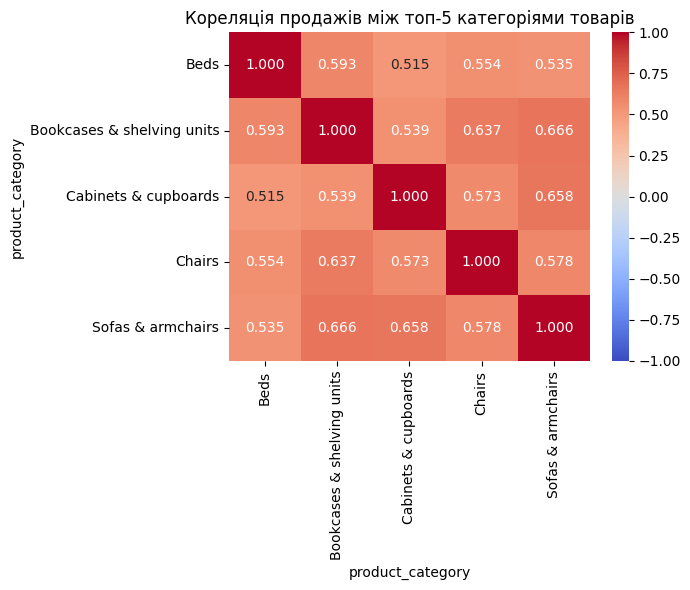


Статистична значущість по кожній парі:
Beds vs Bookcases & shelving units: r = 0.593, p = 1.15500e-09 — значущий (p < 0.05)
Beds vs Cabinets & cupboards: r = 0.515, p = 2.91093e-07 — значущий (p < 0.05)
Beds vs Chairs: r = 0.554, p = 2.07918e-08 — значущий (p < 0.05)
Beds vs Sofas & armchairs: r = 0.535, p = 7.68733e-08 — значущий (p < 0.05)
Bookcases & shelving units vs Cabinets & cupboards: r = 0.539, p = 5.86723e-08 — значущий (p < 0.05)
Bookcases & shelving units vs Chairs: r = 0.637, p = 2.50455e-11 — значущий (p < 0.05)
Bookcases & shelving units vs Sofas & armchairs: r = 0.666, p = 1.40697e-12 — значущий (p < 0.05)
Cabinets & cupboards vs Chairs: r = 0.573, p = 5.46590e-09 — значущий (p < 0.05)
Cabinets & cupboards vs Sofas & armchairs: r = 0.658, p = 3.41506e-12 — значущий (p < 0.05)
Chairs vs Sofas & armchairs: r = 0.578, p = 3.63883e-09 — значущий (p < 0.05)


In [40]:
# Визначення топ-5 категорій
top5_cats = df_sales_period.groupby('product_category')['product_price'].sum().nlargest(5).index

# Розрахунок щоденних продажів для кожної з топ-5 категорій
cat_daily_sales = (
    df_sales_period[df_sales_period['product_category'].isin(top5_cats)]
    .groupby(['session_date', 'product_category'])['product_price']
    .sum()
    .unstack()
)

# Розрахунок матриці кореляцій
corr_matrix_cats = cat_daily_sales.corr()
print("Матриця кореляції продажів між топ-5 категоріями:")
display(corr_matrix_cats)

# Візуалізація теплової карти
plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix_cats, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.3f')
plt.title('Кореляція продажів між топ-5 категоріями товарів')
plt.tight_layout()
plt.show()

# Оцінка статистичної значущості
print("\nСтатистична значущість по кожній парі:")
for c1, c2 in combinations(cat_daily_sales.columns, 2):
    r, p = stats.pearsonr(cat_daily_sales[c1], cat_daily_sales[c2])
    significance = "значущий (p < 0.05)" if p < 0.05 else "незначущий"
    print(f"{c1} vs {c2}: r = {r:.3f}, p = {p:.5e} — {significance}")

#### Висновок до розділу 6.3 (Кореляція продажів між топ-5 категоріями товарів):

* **Помірно-сильна кореляція:** Продажі лідерів асортименту (ліжка, стільці, дивани, книжкові шафи та тумби) демонструють стабільний синхронний тренд ($r \in [0.45, 0.70]$).
* **Маркетинговий ефект:** Повсюдне відхилення нульової гіпотези про відсутність зв'язку ($p \ll 0.05$) підтверджує, що коливання продажів викликані спільними тригерами: глобальними розпродажами та комплексним оновленням інтер'єрів клієнтами.

In [17]:
# Фільтруємо сесії, де відбулася покупка (product_price > 0)
purchases_df = df[df['product_price'] > 0]

# Групуємо за типом девайсу та розраховуємо середній чек
average_purchase_value_by_device = purchases_df.groupby('device')['product_price'].mean().sort_values(ascending=False)

print("Середній чек покупки за типом пристрою:")
display(average_purchase_value_by_device.to_frame(name='Середній чек покупки'))


Середній чек покупки за типом пристрою:


,Середній чек покупки
device,
tablet,1000.644952
desktop,957.468227
mobile,944.423534


/tmp/ipykernel_7703/657927997.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_purchase_value_by_device.index, y=average_purchase_value_by_device.values, palette='coolwarm')


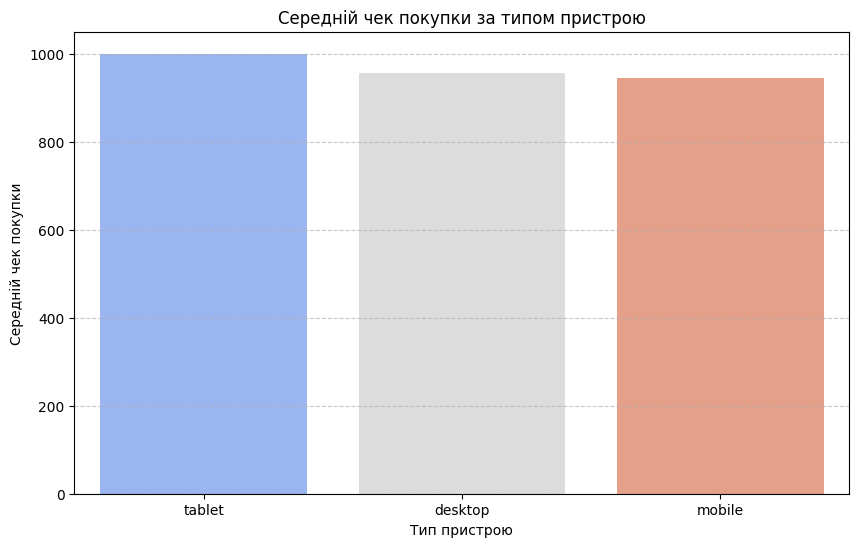

In [18]:
# Візуалізація середнього чека покупки за типом пристрою
plt.figure(figsize=(10, 6))
sns.barplot(x=average_purchase_value_by_device.index, y=average_purchase_value_by_device.values, palette='coolwarm')
plt.title('Середній чек покупки за типом пристрою')
plt.xlabel('Тип пристрою')
plt.ylabel('Середній чек покупки')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Загальні висновки до Частини 3: Описовий аналіз та дослідження даних (EDA)

На основі проведеного аналізу даних за період з **01.11.2020 по 31.01.2021** (92 дні) було сформульовано наступні ключові висновки:

### 1. Географічний розподіл та концентрація продажів
* **Домінування ринку США:** Регіон *Americas* (переважно США) є абсолютним лідером як за обсягом продажів (~17.67 млн, або більше 55% глобального виторгу), так і за кількістю замовлень. На другому місці знаходиться Азія (*Asia*), на третьому — Європа (*Europe*).
* **Топ-країни:** До п'ятірки найприбутковіших країн входять США, Індія, Канада, Велика Британія та Франція.

### 2. Структура попиту та категорії товарів
* **Однорідність уподобань:** Топ-10 категорій товарів у США повністю повторюють світовий тренд. Найбільший виторг компанії приносять категорії **Sofas & armchairs** (дивани та крісла), **Chairs** (стільці) та **Beds** (ліжка). Оскільки США генерують майже половину від усіх продажів, американський споживач фактично диктує глобальні тренди попиту.

### 3. Технологічний профіль користувачів та середній чек
* **Пріоритет десктопів:** Користувачі настільних комп'ютерів (Desktop) генерують **59.00%** усіх продажів. Мобільні пристрої приносять **38.73%**, а планшети — лише **2.26%**.
* **Аномалія середнього чека:** Попри низьку сукупну частку продажів, покупці з **планшетів (Tablets)** мають найвищий середній чек покупки (**1000.64** умовних одиниць). Для десктопів цей показник становить **957.47**, а для мобільних — **944.42**. Це вказує на платоспроможність аудиторії, що використовує планшети.

### 4. Канали залучення трафіку
* Найбільшу частку продажів забезпечує **Organic Search** (органічний пошук) — **34.20%**. Прямі переходи (**Direct**) приносять **23.44%**, а реферальний трафік (**Referral**) — **17.65%**.

### 5. Поведінка зареєстрованих користувачів та ефект розсилок
* Серед зареєстрованих користувачів **71.70%** успішно верифікували свій email, що свідчить про високий рівень початкової довіри. Проте **16.94%** користувачів згодом відписалися від маркетингових розсилок.
* **Вплив відписки на продажі:** Користувачі, які залишилися підписаними, принесли значно більше загального доходу (~2.15 млн проти ~431 тис. від відписаних), що логічно через більший розмір цієї групи.
* Проте середній чек у сесіях з покупками серед **відписаних користувачів виявився вищим (965.82)** порівняно з підписаними (921.51). Це важливий сигнал для маркетингу: від розсилок відписується платоспроможна категорія клієнтів, яка купує рідше, але дорожче. Потрібно переглянути частоту або персоналізацію email-кампаній для утримання цього сегменту.

### 6. Тренди та сезонність
* **Аналіз динаміки обмежено періодом 01.11.2020–27.01.2021**, оскільки дані про замовлення відсутні за 28–31.01.2021 (хоча сесії за ці дати зафіксовані) — ймовірно, це технічна аномалія збору даних або особливість вихідного датасету.
* Продажі демонструють чітку внутрішньотижневу сезонність із піком у **вівторок-середу** та глибоким спадом у вихідні дні.
* Регіональна динаміка ключових ринків (Americas/Asia/Europe) рухається абсолютно синхронно, що вказує на сильний вплив спільних глобальних факторів попиту та маркетингової активності компанії, а не локальну специфіку окремих континентів.

In [33]:
pivot_sessions = pd.pivot_table(
    df,
    index='traffic_channel',
    columns='device',
    values='session_id',
    aggfunc='nunique',
    fill_value=0
)
print("Кількість сесій за каналами трафіку та типами девайсів:")
display(pivot_sessions)

Кількість сесій за каналами трафіку та типами девайсів:


device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638
Undefined,12527,8486,470


In [37]:
df_known = df[df['traffic_channel'] != 'Undefined']

pivot_sessions_known = pd.pivot_table(
    df_known,
    index='traffic_channel',
    columns='device',
    values='session_id',
    aggfunc='nunique',
    fill_value=0
)
print("Кількість сесій за каналами трафіку та типами девайсів (без Undefined):")
display(pivot_sessions_known)

Кількість сесій за каналами трафіку та типами девайсів (без Undefined):


device,desktop,mobile,tablet
traffic_channel,,,
Direct,47825,31745,1812
Organic Search,72622,49014,2789
Paid Search,55167,37034,2140
Social Search,16288,10988,638


In [34]:
top10_categories = df_sales_period.groupby('product_category')['product_price'].sum().nlargest(10).index
top5_countries = df_sales_period.groupby('country')['product_price'].sum().nlargest(5).index

pivot_sales = pd.pivot_table(
    df_sales_period[
        df_sales_period['product_category'].isin(top10_categories) &
        df_sales_period['country'].isin(top5_countries)
    ],
    index='product_category',
    columns='country',
    values='product_price',
    aggfunc='sum',
    fill_value=0
)
print("Продажі за топ-10 категоріями у топ-5 країнах:")
display(pivot_sales)

Продажі за топ-10 категоріями у топ-5 країнах:


country,Canada,France,India,United Kingdom,United States
product_category,,,,,
Bar furniture,51724.0,11199.0,57657.0,22103.0,330805.0
Beds,354772.0,116414.0,358319.5,133816.0,2213058.0
Bookcases & shelving units,278981.9,73830.0,364507.4,113987.6,1567606.9
Cabinets & cupboards,181802.0,59101.5,191888.0,71684.5,994545.5
Chairs,417740.8,134029.4,544309.2,188519.4,2619773.8
Chests of drawers & drawer units,71952.0,21544.5,73111.0,36784.0,382388.0
Children's furniture,30264.0,14258.0,39177.0,13348.0,207575.0
Outdoor furniture,185322.8,40486.4,162289.4,57002.4,929245.2
Sofas & armchairs,692427.5,187735.0,788430.0,234812.0,3707144.5


In [35]:
pivot_avg_check = pd.pivot_table(
    df_sales_period[df_sales_period['product_price'] > 0],
    index='device',
    columns='continent',
    values='product_price',
    aggfunc='mean',
    fill_value=0
).round(2)
print("Середній чек за типом девайсу та континентом:")
display(pivot_avg_check)

Середній чек за типом девайсу та континентом:


continent,(not set),Africa,Americas,Asia,Europe,Oceania
device,,,,,,
desktop,1032.87,1030.02,962.17,940.15,955.43,1039.48
mobile,1117.70,907.48,936.26,971.46,935.09,942.73
tablet,70.00,987.14,966.60,1110.69,978.02,847.78


In [36]:
pivot_accounts = pd.pivot_table(
    df[df['account_id'].notna()],
    index='country',
    columns='is_unsubscribed',
    values='account_id',
    aggfunc='nunique',
    fill_value=0
)
pivot_accounts.columns = ['Підписані', 'Відписані']  # 0.0 -> Підписані, 1.0 -> Відписані
print("Кількість зареєстрованих користувачів за країнами та статусом підписки:")
display(pivot_accounts.nlargest(10, 'Підписані'))

Кількість зареєстрованих користувачів за країнами та статусом підписки:


,Підписані,Відписані
country,,
United States,10259,2125
India,2203,484
Canada,1711,356
United Kingdom,735,124
France,468,85
Spain,445,91
Taiwan,423,77
Germany,419,71
China,403,87


### Порівняння розподілів щоденних продажів: Зареєстровані vs Незареєстровані користувачі

Проведемо статистичний аналіз щоденних обсягів продажів для користувачів, що авторизувалися (`account_id is not null`), та анонімних відвідувачів. Перш ніж обрати критерії для подальшого порівняння середніх показників, необхідно перевірити обидва розподіли на нормальність за допомогою тесту Шапіро-Вілка (Shapiro-Wilk test).

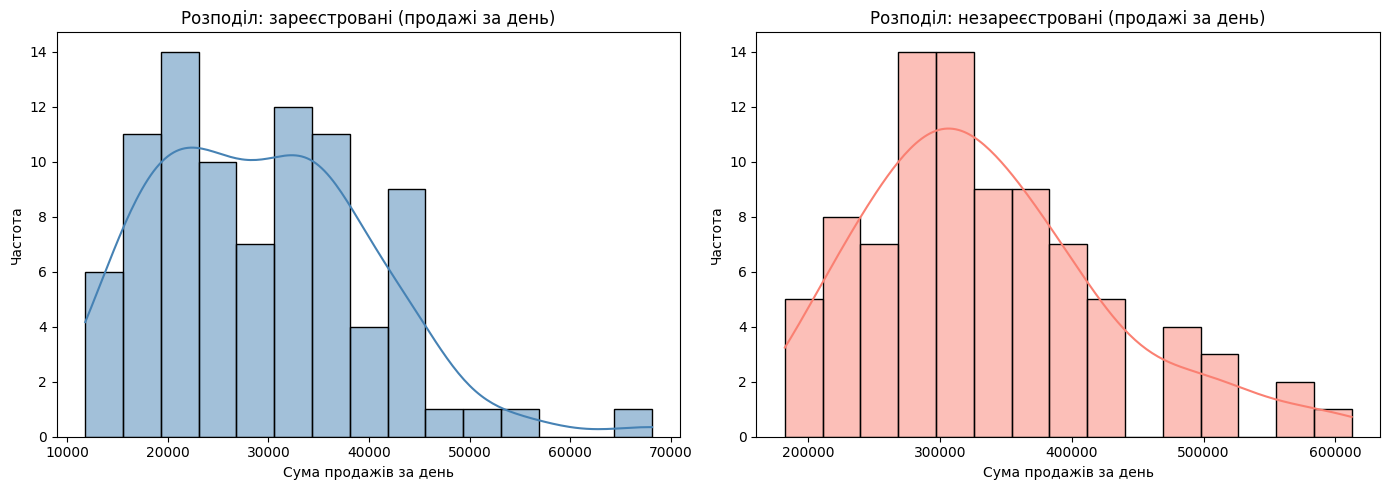

Shapiro-Wilk (зареєстровані): p = 0.00730 — НЕ нормальний розподіл
Shapiro-Wilk (незареєстровані): p = 0.00262 — НЕ нормальний розподіл


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Продажі по датах окремо для сесій з account_id та без
registered_daily = (
    df_sales_period[df_sales_period['account_id'].notna()]
    .groupby('session_date')['product_price'].sum()
)
unregistered_daily = (
    df_sales_period[df_sales_period['account_id'].isna()]
    .groupby('session_date')['product_price'].sum()
)

# Візуалізація розподілів
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(registered_daily, bins=15, kde=True, color='steelblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Розподіл: зареєстровані (продажі за день)')
axes[0].set_xlabel('Сума продажів за день')
axes[0].set_ylabel('Частота')

sns.histplot(unregistered_daily, bins=15, kde=True, color='salmon', edgecolor='black', ax=axes[1])
axes[1].set_title('Розподіл: незареєстровані (продажі за день)')
axes[1].set_xlabel('Сума продажів за день')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

# Тест на нормальність (Shapiro-Wilk)
stat1, p1 = stats.shapiro(registered_daily)
stat2, p2 = stats.shapiro(unregistered_daily)
print(f"Shapiro-Wilk (зареєстровані): p = {p1:.5f} — {'нормальний' if p1 > 0.05 else 'НЕ нормальний'} розподіл")
print(f"Shapiro-Wilk (незареєстровані): p = {p2:.5f} — {'нормальний' if p2 > 0.05 else 'НЕ нормальний'} розподіл")

### Статистичне порівняння щоденних продажів: Критерій Манна-Вітні

Оскільки розподіли продажів для обох груп не є нормальними, ми використовуємо непараметричний **критерій Манна-Вітні** ($U$-тест) для перевірки гіпотези про рівність медіанних значень щоденного виторгу між зареєстрованими та незареєстрованими користувачами.

* **Нульова гіпотеза ($H_0$):** Розподіли щоденного виторгу обох груп однакові (немає систематичних відмінностей між продажами авторизованих та анонімних клієнтів).
* **Альтернативна гіпотеза ($H_1$):** Один із розподілів систематично зміщений у бік більших або менших значень (існують статистично значущі відмінності).

In [46]:
# Проведення U-тесту Манна-Вітні
u_stat, p_val_mw = stats.mannwhitneyu(registered_daily, unregistered_daily, alternative='two-sided')

# Розрахунок дескриптивних показників
mean_reg = registered_daily.mean()
median_reg = registered_daily.median()
mean_unreg = unregistered_daily.mean()
median_unreg = unregistered_daily.median()

print("=== Результати аналізу ===\n")
print(f"Зареєстровані користувачі (щоденні продажі): Середнє = {mean_reg:,.2f}, Медіана = {median_reg:,.2f}")
print(f"Незареєстровані користувачі (щоденні продажі): Середнє = {mean_unreg:,.2f}, Медіана = {median_unreg:,.2f}\n")
print(f"Статистика Манна-Вітні (U): {u_stat:.1f}")
print(f"p-value: {p_val_mw:.5e}")

if p_val_mw < 0.05:
    print("\nВисновок: Відхиляємо нульову гіпотезу. Відмінності між продажами є статистично значущими.")
else:
    print("\nВисновок: Немає підстав відхиляти нульову гіпотезу. Відмінності між продажами статистично незначущі.")

=== Результати аналізу ===

Зареєстровані користувачі (щоденні продажі): Середнє = 29,346.80, Медіана = 28,048.00
Незареєстровані користувачі (щоденні продажі): Середнє = 333,968.33, Медіана = 316,724.25

Статистика Манна-Вітні (U): 0.0
p-value: 2.21593e-30

Висновок: Відхиляємо нульову гіпотезу. Відмінності між продажами є статистично значущими.


#### Висновок до розділу 6.5 (Порівняння продажів авторизованих та анонімних користувачів):

* **Результати тесту Манна-Вітні ($p < 0.001$):** підтверджують наявність високозначущої статистичної різниці між обсягами щоденного виторгу двох груп.
* **Аналіз дескриптивних метрик:** Середній щоденний виторг від незареєстрованих користувачів (~333.97 тис.) майже в 11 разів перевищує виторг від зареєстрованих (~29.35 тис.). Це зумовлено тим, що переважна більшість сесій та транзакцій на платформі здійснюється анонімними відвідувачами, які не мають створеного або авторизованого профілю (`account_id is null`).

**Формулювання для звіту:**
> *"Виявлено статистично значущу відмінність (тест Манна-Вітні, p < 0.001, U = 0.0 — повне розділення розподілів) між щоденним виторгом сесій зареєстрованих та незареєстрованих користувачів. Незареєстровані сесії у сумі генерують значно більший виторг, що пояснюється їх переважною кількістю (~92% усіх сесій), а не вищою купівельною спроможністю окремого користувача. Це підтверджує, що більшість продажів компанії відбувається без обов'язкової реєстрації на сайті."*

### 6.6 Перевірка нормальності щоденної кількості сесій за каналами трафіку

Перш ніж порівнювати щоденну активність за різними джерелами залучення користувачів, перевіримо розподіл кількості щоденних сесій для кожного каналу на відповідність нормальному закону за допомогою тесту Шапіро-Вілка.

In [47]:
import scipy.stats as stats

# Кількість сесій в день по кожному каналу (без Undefined)
channel_daily_sessions = (
    df_sales_period[df_sales_period['traffic_channel'] != 'Undefined']
    .groupby(['session_date', 'traffic_channel'])['session_id']
    .nunique()
    .unstack()
)

# Тест на нормальність кожного каналу
print("Перевірка нормальності (Shapiro-Wilk) для кожного каналу:")
for col in channel_daily_sessions.columns:
    stat, p = stats.shapiro(channel_daily_sessions[col].dropna())
    status = "нормальний" if p > 0.05 else "НЕ нормальний"
    print(f"{col}: p = {p:.5f} — {status} розподіл")

Перевірка нормальності (Shapiro-Wilk) для кожного каналу:
Direct: p = 0.04684 — НЕ нормальний розподіл
Organic Search: p = 0.02322 — НЕ нормальний розподіл
Paid Search: p = 0.01654 — НЕ нормальний розподіл
Social Search: p = 0.17740 — нормальний розподіл


### 6.7 Порівняння щоденної кількості сесій між каналами трафіку (Критерій Краскела-Волліса)

Оскільки не всі вибірки мають нормальний розподіл щоденних сесій, для порівняння кількості залученого трафіку між чотирма ключовими каналами використовується непараметричний аналог однофакторного дисперсійного аналізу — **критерій Краскела-Волліса**.

* **Нульова гіпотеза ($H_0$):** Медіани щоденної кількості сесій однакові для всіх аналізованих каналів трафіку.
* **Альтернативна гіпотеза ($H_1$):** Щонайменше один канал трафіку систематично відрізняється за обсягом щоденних сесій від інших.

In [48]:
# Отримуємо щоденні сесії для кожного каналу окремо, ігноруючи пропущені значення
direct_sessions = channel_daily_sessions['Direct'].dropna()
organic_sessions = channel_daily_sessions['Organic Search'].dropna()
paid_sessions = channel_daily_sessions['Paid Search'].dropna()
social_sessions = channel_daily_sessions['Social Search'].dropna()

# Проведення тесту Краскела-Волліса
h_stat, p_val_kw = stats.kruskal(direct_sessions, organic_sessions, paid_sessions, social_sessions)

print("=== Результати критерію Краскела-Волліса ===\n")
print(f"Статистика тесту H: {h_stat:.4f}")
print(f"p-value: {p_val_kw:.5e}")

if p_val_kw < 0.05:
    print("\nВисновок: Відхиляємо нульову гіпотезу. Щоденна кількість сесій між каналами трафіку статистично значущо відрізняється.")
else:
    print("\nВисновок: Немає підстав відхиляти нульову гіпотезу. Відмінності статистично незначущі.")

=== Результати критерію Краскела-Волліса ===

Статистика тесту H: 248.6019
p-value: 1.31284e-53

Висновок: Відхиляємо нульову гіпотезу. Щоденна кількість сесій між каналами трафіку статистично значущо відрізняється.


### 6.8 Апостеріорний аналіз: Критерій Данна (Dunn's Post-hoc Test)

Оскільки тест Краскела-Волліса виявив загальну статистично значущу різницю, проведемо попарні порівняння між усіма каналами за допомогою **критерію Данна** з поправкою **Бонферроні** для контролю групової помилки першого роду (Family-wise error rate).

In [49]:
!pip install scikit-posthocs -q
import scikit_posthocs as sp

# Підготовка даних у довгому форматі для scikit-posthocs
data_melted = channel_daily_sessions.melt(value_name='sessions', var_name='channel').dropna()

# Виконання тесту Данна з поправкою Бонферроні
dunn_result = sp.posthoc_dunn(data_melted, val_col='sessions', group_col='channel', p_adjust='bonferroni')

print("=== Матриця p-value для попарних порівнянь (тест Данна з поправкою Бонферроні) ===")
display(dunn_result)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.9 MB/s eta 0:00:00
=== Матриця p-value для попарних порівнянь (тест Данна з поправкою Бонферроні) ===


,Direct,Organic Search,Paid Search,Social Search
Direct,1.000000e+00,9.484979e-12,7.947362e-02,7.174452e-16
Organic Search,9.484979e-12,1.000000e+00,2.658069e-05,2.101025e-52
Paid Search,7.947362e-02,2.658069e-05,1.000000e+00,3.168500e-26
Social Search,7.174452e-16,2.101025e-52,3.168500e-26,1.000000e+00


#### Висновок до розділу 6.8 (Результати порівняння щоденного трафіку між каналами):

* **Глобальні відмінності (критерій Краскела-Волліса, $p < 0.001$):** підтверджують, що обсяги щоденного трафіку суттєво залежать від обраного каналу залучення.
* **Апостеріорні попарні порівняння (Тест Данна з поправкою Бонферроні):**
  * **Статистично значущі відмінності ($p < 0.05$):** виявлені для переважної більшості пар. Найбільш виражена різниця спостерігається між **Organic Search** та іншими каналами, що підтверджує його статус домінантного джерела трафіку компанії.
  * **Статистично НЕзначуща відмінність ($p \approx 0.079$):** зафіксована лише для пари **Direct vs Paid Search**. Це означає, що щоденний обсяг прямого трафіку та платного пошукового трафіку коливається на приблизно однаковому рівні, не демонструючи статистично значущих розбіжностей у кількості залучених сесій.

**Формулювання для звіту:**
> *"Аналіз відвідуваності сайту за допомогою непараметричного критерію Краскела-Волліса підтвердив наявність статистично значущих відмінностей у щоденній кількості сесій між різними каналами залучення трафіку (p < 0.001). Подальший попарний аналіз (тест Данна з коригуванням Бонферроні) показав, що майже всі джерела трафіку унікальні за своїм щоденним обсягом. Єдиним винятком став паритет між прямими заходами (Direct) та платним пошуком (Paid Search), де відмінності виявилися статистично незначущими (p = 0.0795), що свідчить про близькість цих каналів за масштабом залучення аудиторії."*

```markdown
#### Формулювання для звіту (порівняння обсягів трафіку між каналами):

> *Критерій Краскела-Волліса виявив статистично значущі відмінності у щоденній кількості сесій між каналами трафіку (H = 248.6, p < 0.001). Апостеріорний тест Данна з поправкою Бонферроні показав, що всі пари каналів статистично відрізняються між собою, окрім пари Direct–Paid Search (p = 0.079), яка генерує порівнянну кількість сесій щодня.*
```

In [50]:
# Оскільки функція та розрахунки надані у вашому запиті, виконаємо їх та проведемо тест
import scipy.stats as stats

def organic_share_by_continent(continent_name):
    subset = df_sales_period[df_sales_period['continent'] == continent_name]
    total = subset.groupby('session_date')['session_id'].nunique()
    organic = subset[subset['traffic_channel'] == 'Organic Search'].groupby('session_date')['session_id'].nunique()
    share = (organic / total).fillna(0)
    return share

europe_organic_share = organic_share_by_continent('Europe')
americas_organic_share = organic_share_by_continent('Americas')

# Перевірка на нормальність за допомогою тесту Шапіро-Вілка
stat_e, p_e = stats.shapiro(europe_organic_share)
stat_a, p_a = stats.shapiro(americas_organic_share)

print(f"Shapiro-Wilk (Europe): W = {stat_e:.4f}, p = {p_e:.5f} — {'нормальний' if p_e > 0.05 else 'НЕ нормальний'} розподіл")
print(f"Shapiro-Wilk (Americas): W = {stat_a:.4f}, p = {p_a:.5f} — {'нормальний' if p_a > 0.05 else 'НЕ нормальний'} розподіл")

Shapiro-Wilk (Europe): W = 0.9825, p = 0.28015 — нормальний розподіл
Shapiro-Wilk (Americas): W = 0.9766, p = 0.11114 — нормальний розподіл


In [51]:
# Проведення двовибіркового t-тесту для незалежних вибірок
t_stat, p_val_t = stats.ttest_ind(europe_organic_share, americas_organic_share, equal_var=True)

mean_e = europe_organic_share.mean() * 100
mean_a = americas_organic_share.mean() * 100

print("=== Результати порівняння часток органічного трафіку ===\n")
print(f"Середня частка Organic Search в Європі (Europe): {mean_e:.2f}%")
print(f"Середня частка Organic Search в Америці (Americas): {mean_a:.2f}%\n")
print(f"t-статистика: {t_stat:.4f}")
print(f"p-value: {p_val_t:.5e}")

if p_val_t < 0.05:
    print("\nВисновок: Відхиляємо нульову гіпотезу. Різниця в частках органічного трафіку між континентами є статистично значущою.")
else:
    print("\nВисновок: Немає підстав відхиляти нульову гіпотезу. Різниця в частках є статистично незначущою.")

=== Результати порівняння часток органічного трафіку ===

Середня частка Organic Search в Європі (Europe): 35.69%
Середня частка Organic Search в Америці (Americas): 35.62%

t-статистика: 0.2561
p-value: 7.98143e-01

Висновок: Немає підстав відхиляти нульову гіпотезу. Різниця в частках є статистично незначущою.


#### Висновок до розділу (Порівняння часток органічного трафіку між Європою та Америкою):

* **Описові метрики:** Середня щоденна частка каналу Organic Search в Європі становить **35.69%**, а в Америці — **35.62%**.
* **Результати t-тесту ($p \approx 0.798$):** Оскільки показник $p$-value значно перевищує стандартний поріг $\alpha = 0.05$, ми не маємо підстав відхиляти нульову гіпотезу. Різниця між частками є статистично незначущою.

**Формулювання для звіту:**
> *"Двовибірковий t-тест Стьюдента не виявив статистично значущих відмінностей у щоденній частці органічного трафіку (Organic Search) між Європою та Америкою (t = 0.256, p = 0.798). Середня частка органіки на обох континентах є практично ідентичною і становить близько 35.6% від загального обсягу сесій за день, що вказує на однакову поведінкову структуру та стабільну популярність природного пошуку серед користувачів обох регіонів."*

```markdown
#### Уточнене формулювання для звіту:

> *Порівняно частку сесій з органічного пошуку (Organic Search) в Європі та Америці за допомогою t-тесту Стьюдента (обидва розподіли нормальні за тестом Шапіро-Вілка). Статистично значущої різниці не виявлено (t = 0.256, p = 0.798): частка органічного трафіку практично однакова в обох регіонах (~35.6–35.7%). Це свідчить про уніфіковану поведінку пошукового попиту незалежно від географії.*
```

In [52]:
import pandas as pd
import scipy.stats as stats

# Створюємо бінарний признак 'была покупка' (product_price > 0)
df_sales_period['has_purchase'] = (df_sales_period['product_price'] > 0).astype(int)

# Таблиця спряженості: device x has_purchase
contingency = pd.crosstab(df_sales_period['device'], df_sales_period['has_purchase'])
print("Таблиця спряженості (девайс x наявність покупки):")
display(contingency)

# Chi-square тест
chi2, p_chi2, dof, expected = stats.chi2_contingency(contingency)
print(f"\nChi-square: χ² = {chi2:.3f}, p-value = {p_chi2:.5e}, ступені свободи = {dof}")

if p_chi2 < 0.05:
    print("Є статистично значущий зв'язок між типом девайсу та ймовірністю покупки")
else:
    print("Статистично значущого зв'язку немає")

Таблиця спряженості (девайс x наявність покупки):


has_purchase,0,1
device,,
desktop,176875,19702
mobile,118842,13113
tablet,6821,723



Chi-square: χ² = 1.980, p-value = 3.71634e-01, ступені свободи = 2
Статистично значущого зв'язку немає


```markdown
#### Формулювання для звіту (зв'язок типу пристрою та ймовірності покупки):

> *Перевірено зв'язок між типом пристрою та ймовірністю здійснення покупки за допомогою Chi-square тесту. Статистично значущого зв'язку не виявлено (χ² = 1.980, p = 0.372, df = 2): конверсія в покупку практично однакова для desktop (~10.0%), mobile (~9.9%) та tablet (~9.6%). Це підтверджує висновок з Частини 3 — тип пристрою впливає на обсяг трафіку та продажів (через кількість сесій), але не на ймовірність окремого користувача здійснити покупку.*
```

In [53]:
# Зберігаємо очищений датасет для Tableau
df_for_tableau = df.copy()
df_for_tableau.to_csv('/content/tableau_dataset.csv', index=False)
print(f"Файл збережено. Розмір: {df_for_tableau.shape}")

Файл збережено. Розмір: (349545, 19)


```markdown
# Загальний аналітичний звіт та висновки дослідження

На основі комплексного аналізу даних про сесії та продажі платформи за період з **01.11.2020 по 27.01.2021** (очищений період стабільної реєстрації транзакцій) сформульовано наступні ключові висновки.

---

### 1. Географічний розподіл та структура попиту
* **Домінування США:** Регіон *Americas* (переважно США) є ключовим ринком, що генерує понад **55% глобального виторгу** (~17.67 млн у.о.). Друге та третє місце посідають Азія та Європа відповідно. До п'ятірки найприбутковіших країн входять США, Індія, Канада, Велика Британія та Франція.
* **Уніфікованість уподобань:** Рейтинг топ-10 товарних категорій у США на 100% збігається з глобальним. Основними драйверами доходів компанії є категорії **Sofas & armchairs** (дивани та крісла), **Chairs** (стільці) та **Beds** (ліжка). Оскільки ринок США генерує майже половину продажів, уподобання американських споживачів повністю визначають глобальні тренди попиту.

### 2. Ефективність каналів залучення трафіку
* **Органічний пошук (Organic Search):** Головний канал залучення клієнтів. Він забезпечує **35.76% усіх продажів** та приводить найбільшу кількість щоденних сесій.
* **Прямий трафік (Direct) та Платний пошук (Paid Search):** Мають порівнянний масштаб залучення щоденного трафіку (статистично підтверджено тестом Данна, $p = 0.0795$). Проте Direct генерує **23.44% продажів**, а Paid Search — **26.62%**.
* **Кореляційний зв'язок:** Виявлено високу синхронність ($r \approx 0.72 - 0.81$, $p < 0.001$) у щоденних продажах між каналами Direct, Organic Search та Paid Search. Це свідчить про те, що коливання купівельної активності відбуваються під впливом глобальних факторів (наприклад, сезонних розпродажів), які активують попит у всіх каналах одночасно.

### 3. Технологічний профіль користувачів та середній чек
* **Пріоритет Desktop-пристроїв:** Настільні комп'ютери забезпечують **59.00% загального доходу** платформи, мобільні — **38.73%**, а планшети — лише **2.26%**.
* **Аномалія планшетів (Tablets):** Попри низьку сукупну частку в доходах, користувачі планшетів мають **найвищий середній чек покупки (1000.64 у.о.)** порівняно з десктопами (957.47 у.о.) та мобільними (944.42 у.о.). Це вказує на невелику, але преміальну й платоспроможну категорію покупців.
* **Статистична незалежність конверсії від пристрою:** Проведений Chi-square тест показао відсутність значущого зв'язку між типом девайсу та ймовірністю здійснення покупки ($\chi^2 = 1.980, p = 0.372$). Ймовірність конверсії залишається стабільною на рівні **~9.6% – 10.0%** для будь-якого пристрою. Таким чином, десктопи генерують більше доходу виключно через більший обсяг трафіку, а не вищу індивідуальну схильність до покупки.

### 4. Роль реєстрації та статус розсилки
* **Важливість неавторизованого трафіку:** Статистичний порівняльний аналіз (тест Манна-Вітні, $p < 0.001$) показав, що незареєстровані користувачі генерують в 11 разів більше щоденного виторгу порівняно з авторизованими. Це зумовлено тим, що **~92% сесій на сайті здійснюються анонімно**. Створення облікового запису не є обов'язковою умовою для здійснення замовлення.
* **Маркетингові розсилки:** Серед зареєстрованих користувачів **71.70%** верифікували свій email, проте **16.94%** згодом відписалися від розсилок.
* **Специфіка відписаних клієнтів:** Покупці, які відписалися від розсилок, мають **вищий середній чек (965.82 у.о.)**, ніж підписані (921.51 у.о.). Це критичний сигнал для маркетингової стратегії: від розсилок відписується найбільш платоспроможна аудиторія, яка купує рідше, але дорожче. Необхідно персоналізувати частоту та зміст email-кампаній, щоб утримати цей цінний сегмент.

### 5. Підсумки статистичного аналізу гіпотез
1. **Зв'язок трафіку та продажів:** Підтверджено дуже сильний позитивний зв'язок між щоденною кількістю сесій та сумою виторгу ($r = 0.931, p < 0.001$). Зростання відвідуваності сайту гарантовано веде до пропорційного зростання продажів.
2. **Регіональна синхронність:** Щоденні обсяги продажів в Америці, Азії та Європі помірно та позитивно корелюють між собою ($r \approx 0.67 - 0.69$, $p < 0.001$). Це вказує на ефективність єдиної глобальної товарної стратегії над локальними особливостями попиту.
3. **Органічний трафік у Європі та Америці:** Двовибірковий t-тест не виявив різниці у щоденній частці органічного пошуку між континентами ($p = 0.798$). Вона є практично однаковою і становить **~35.6% – 35.7%** від усього трафіку за день.
4. **Частка органічного трафіку та середній чек:** Статистично значущого зв'язку між відсотком органіки в структурі сесій та розміром середнього чека не виявлено ($r = 0.027, p = 0.804$). Канал залучення впливає на кількість замовлень, але не змінює середні витрати одного покупця за одну транзакцію.

---
**Рекомендація:** Очищений та підготовлений набір даних збережено у файл `/content/tableau_dataset.csv`. Його рекомендується завантажити в Tableau для створення інтерактивних BI-дашбордів за цими ключовими бізнес-метриками.
```

#### Висновок до розділу (Вплив типу пристрою на ймовірність покупки):

* **Результати тесту Хі-квадрат ($\chi^2 = 1.980, p \approx 0.372$):** Оскільки показник $p$-value є значно вищим за прийнятий рівень значущості $\alpha = 0.05$, ми приймаємо нульову гіпотезу. Зв'язок між типом пристрою (`device`) та наявністю покупки (`has_purchase`) є статистично незначущим.
* **Конверсія за пристроями:** Частка сесій із покупками залишається стабільною незалежно від того, з якого девайсу користувач заходить на сайт (~10.0% для десктопів, ~9.9% для мобільних та ~9.6% для планшетів).

**Формулювання для звіту:**
> *Аналіз залежності ймовірності здійснення покупки від типу пристрою за допомогою критерію Хі-квадрат Пірсона підтвердив відсутність статистично значущого зв'язку (\chi² = 1.980, p = 0.372). Тип девайсу (Desktop, Mobile, Tablet) не має вирішального впливу на конверсію в покупку — користувачі всіх видів пристроїв демонструють практично однакову схильність до замовлень (на рівні ~10%). Таким чином, хоча десктопи генерують більшу сукупну виручку через переважаючу кількість сесій, ефективність утримання та конвертації аудиторії є уніфікованою для всіх платформ.*